# SVEIR Compartmental Model
The SVEIR model tracks how a population splits into five distinct categories over time. Its dynamics are governed by a system of non-linear Ordinary Differential Equations (ODEs): 

$$ \frac{dS}{dt}=\mu N-\beta \frac{S\cdot I}{N}-(\theta +\mu)S $$
$$ \frac{dV}{dt}=\theta S-\sigma \beta \frac{V\cdot I}{N}-\mu V $$
$$ \frac{dE}{dt}=\beta \frac{S\cdot I}{N}+\sigma \beta \frac{V\cdot I}{N}-(\alpha +\mu )E $$
$$ \frac{dI}{dt}=\alpha E-(\gamma +\delta +\mu )I $$
$$ \frac{dR}{dt}=\gamma I-\mu R $$

Where the vital and disease-specific parameters include:<br>
μ: Natural birth/death rate.<br>
β: Transmission (contact) rate.<br>
θ: Vaccination rate.<br>
σ: Vaccine imperfection factor (fractional susceptibility of vaccinated individuals).<br>
α: Progression rate from exposed to infectious (1/α is the incubation period).<br>
γ, δ: Recovery and COVID-induced mortality rates, respectively.

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path

import os, random
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


# Output directory
OUT = Path('/kaggle/working/COVID19_SVEIR_RK4_PINN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)


# SVEIR PARAMETERS
BETA = 0.17150948   # Transmission rate for susceptible individuals
GAMMA = 0.09425424  # Recovery rate
SIGMA = 1.0 / 5.2   # Rate at which exposed individuals become infectious

# New SVEIR Specific Parameters
XI = 0.015          # Vaccination rate (fraction of susceptible population vaccinated per day)
EPSILON = 0.25      # Vaccine leaks/efficacy factor (e.g., 0.25 means 75% vaccine efficacy)


# Initial conditions
S0 = 999000.0
V0 = 0.0            # Initially no one is vaccinated
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population (N remains constant if no vital dynamics)
N = S0 + V0 + E0 + I0 + R0


# TIME SETTINGS
T0 = 0.0
T1 = 5000.0
H = 0.5


# FNN SETTINGS
SEED = 42
EPOCHS = 200
BATCH_SIZE = 32

# Hidden layers modified slightly if needed to capture 5 input/output features instead of 4
HIDDEN = [16, 32, 256, 128, 80, 40, 16]


# RANDOM SEED
os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# Imports Libraries

In [2]:
# =============================================================================
# SVEIR-PINN
# =============================================================================
# PROPERLY OPTIMIZED PHYSICS-INFORMED NEURAL NETWORK 
# FOR THE NORMALIZED SVEIR MODEL
# =============================================================================

import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

# Global Configuration and define SVEIR Parameters

In [3]:
# =============================================================================
# GLOBAL CONFIGURATION
# =============================================================================

tf.keras.backend.set_floatx("float64")

DTYPE = tf.float64
NP_DTYPE = np.float64

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# =============================================================================
# SVEIR PARAMETERS
# =============================================================================

BETA = 0.17150948   # Transmission rate for susceptible individuals
GAMMA = 0.09425424  # Recovery rate
SIGMA = 1.0 / 5.2   # Rate at which exposed individuals become infectious

# New SVEIR Specific Parameters
XI = 0.015          # Vaccination rate (fraction of susceptible population vaccinated per day)
EPSILON = 0.25      # Vaccine leaks/efficacy factor (e.g., 0.25 means 75% vaccine efficacy)


# Initial conditions
S0 = 999000.0
V0 = 0.0            # Initially no one is vaccinated
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population (N remains constant if no vital dynamics)
N = S0 + V0 + E0 + I0 + R0

s0 = S0 / N
v0 = V0 / N
e0 = E0 / N
i0 = I0 / N
r0 = R0 / N



print("=" * 90)
print("SVEIR-PINN")
print("=" * 90)

print(f"Population N        = {N:,.0f}")
print(f"Beta                = {BETA:.8f}")
print(f"Gamma               = {GAMMA:.8f}")
print(f"SIGMA               = {SIGMA:.8f}")
print(f"XI                  = {XI:.8f}")
print(f"EPSILON             = {EPSILON:.8f}")
print(f"Basic reproduction R0 = {BETA / GAMMA:.8f}")

print()
print("Initial conditions")
print("-" * 90)

print(f"S0 = {S0:,.4f}")
print(f"V0 = {V0:,.4f}")
print(f"E0 = {E0:,.4f}")
print(f"I0 = {I0:,.4f}")
print(f"R0 = {R0:,.4f}")

print()
print("Normalized initial conditions")

print(f"s0 = {s0:.12f}")
print(f"v0 = {v0:.12f}")
print(f"e0 = {e0:.12f}")
print(f"i0 = {i0:.12f}")
print(f"r0 = {r0:.12f}")

SVEIR-PINN
Population N        = 1,000,000
Beta                = 0.17150948
Gamma               = 0.09425424
SIGMA               = 0.19230769
XI                  = 0.01500000
EPSILON             = 0.25000000
Basic reproduction R0 = 1.81964737

Initial conditions
------------------------------------------------------------------------------------------
S0 = 999,000.0000
V0 = 0.0000
E0 = 0.0000
I0 = 1,000.0000
R0 = 0.0000

Normalized initial conditions
s0 = 0.999000000000
v0 = 0.000000000000
e0 = 0.000000000000
i0 = 0.001000000000
r0 = 0.000000000000


# TIME CONFIGURATION

In [4]:
# =============================================================================
# TIME CONFIGURATION
# =============================================================================

TRAIN_START = 0.0
TRAIN_END = 100.0

EVAL_END = 200.0

TIME_SCALE = TRAIN_END


print()
print("=" * 90)
print("TIME CONFIGURATION")
print("=" * 90)

print(f"Training interval      : {TRAIN_START:.1f} - {TRAIN_END:.1f} days")
print(f"Extrapolation interval : {TRAIN_END:.1f} - {EVAL_END:.1f} days")
print(f"Time normalization     : tau = t / {TIME_SCALE:.1f}")


TIME CONFIGURATION
Training interval      : 0.0 - 100.0 days
Extrapolation interval : 100.0 - 200.0 days
Time normalization     : tau = t / 100.0


# RK4 Solution

In [5]:
# =============================================================================
# RK4 SOLVER (SVEIR MODEL)
# =============================================================================

def sveir_rhs(y, beta, xi, epsilon, sigma, gamma, N):

    s, v, e, i, r = y

    # Normalized transmission terms
    inf_s = (beta * s * i) / N
    inf_v = (epsilon * beta * v * i) / N
    vac_s = xi * s

    ds = -inf_s - vac_s
    dv = vac_s - inf_v
    de = inf_s + inf_v - sigma * e
    di = sigma * e - gamma * i
    dr = gamma * i

    return np.array(
        [ds, dv, de, di, dr],
        dtype=np.float64
    )


def rk4_sveir(
    beta,
    xi,
    epsilon,
    sigma,
    gamma,
    s0,
    v0,
    e0,
    i0,
    r0,
    t_start=0.0,
    t_end=200.0,
    h=0.02
):

    # Compute constant total population N
    N = s0 + v0 + e0 + i0 + r0

    n_steps = int(
        round(
            (t_end - t_start) / h
        )
    )

    t = np.linspace(
        t_start,
        t_end,
        n_steps + 1,
        dtype=np.float64
    )

    # Matrix dimensions updated to track 5 components
    y = np.zeros(
        (n_steps + 1, 5),
        dtype=np.float64
    )

    y[0] = [
        s0,
        v0,
        e0,
        i0,
        r0
    ]

    for k in range(n_steps):

        yk = y[k]

        k1 = sveir_rhs(
            yk,
            beta,
            xi,
            epsilon,
            sigma,
            gamma,
            N
        )

        k2 = sveir_rhs(
            yk + 0.5 * h * k1,
            beta,
            xi,
            epsilon,
            sigma,
            gamma,
            N
        )

        k3 = sveir_rhs(
            yk + 0.5 * h * k2,
            beta,
            xi,
            epsilon,
            sigma,
            gamma,
            N
        )

        k4 = sveir_rhs(
            yk + h * k3,
            beta,
            xi,
            epsilon,
            sigma,
            gamma,
            N
        )

        y[k + 1] = (
            yk
            + h / 6.0
            * (
                k1
                + 2.0 * k2
                + 2.0 * k3
                + k4
            )
        )

    return t, y

## Compute RK4 Reference

In [6]:
# =============================================================================
# COMPUTE RK4 REFERENCE (SVEIR MODEL)
# =============================================================================

print()
print("=" * 90)
print("COMPUTING RK4 REFERENCE SOLUTION")
print("=" * 90)

rk4_start = time.time()

# Notice the updated function name and structural arguments
t_rk4, y_rk4 = rk4_sveir(
    BETA,
    XI,
    EPSILON,
    SIGMA,
    GAMMA,
    s0,        # Ensure these match your script's variable casing
    v0,
    e0,
    i0,
    r0,
    0.0,
    EVAL_END,
    h=0.02
)

rk4_time = time.time() - rk4_start

# Extract individual fractional channels
s_rk4 = y_rk4[:, 0]
v_rk4 = y_rk4[:, 1]
e_rk4 = y_rk4[:, 2]
i_rk4 = y_rk4[:, 3]
r_rk4 = y_rk4[:, 4]

# Scale up by total population N
S_rk4 = s_rk4 * N
V_rk4 = v_rk4 * N
E_rk4 = e_rk4 * N
I_rk4 = i_rk4 * N
R_rk4 = r_rk4 * N

print(f"RK4 time = {rk4_time:.3f} seconds")
print(f"Number of RK4 points = {len(t_rk4):,}")


COMPUTING RK4 REFERENCE SOLUTION
RK4 time = 0.237 seconds
Number of RK4 points = 10,001


## RK4 Sanity Check

In [7]:
# =============================================================================
# RK4 SANITY CHECK (SVEIR MODEL)
# =============================================================================

rk4_peak_idx = np.argmax(I_rk4)

print()
print("=" * 90)
print("RK4 SANITY CHECK")
print("=" * 90)

print(
    f"Peak infected       = "
    f"{I_rk4[rk4_peak_idx]:,.6f}"
)

print(
    f"Peak infection time = "
    f"{t_rk4[rk4_peak_idx]:.4f} days"
)

# Checks that s + v + e + i + r equals 1.0 across all steps
print(
    f"Maximum conservation error = "
    f"{np.max(np.abs(y_rk4.sum(axis=1) - 1.0)):.3e}"
)



RK4 SANITY CHECK
Peak infected       = 2,368.232640
Peak infection time = 62.8400 days
Maximum conservation error = 4.219e-15


# Create Training Data

In [8]:
# =============================================================================
# CREATE TRAINING DATA (SVEIR MODEL)
# =============================================================================
#
# RK4 data are used ONLY from 0-100 days.
#
# 100-200 days are completely withheld from training.
#
# =============================================================================

train_time = np.linspace(
    TRAIN_START,
    TRAIN_END,
    101,
    dtype=np.float64
)

train_indices = np.searchsorted(
    t_rk4,
    train_time
)

# Extracting all 5 fractional components from the RK4 solution arrays
train_s = s_rk4[train_indices]
train_v = v_rk4[train_indices]
train_e = e_rk4[train_indices]
train_i = i_rk4[train_indices]
train_r = r_rk4[train_indices]

# Stacking into a shape of (N_samples, 5)
train_y = np.column_stack([
    train_s,
    train_v,
    train_e,
    train_i,
    train_r
])

## TRAIN / VALIDATION SPLIT

In [9]:

# =============================================================================
# TRAIN / VALIDATION SPLIT (SVEIR MODEL)
# =============================================================================
#
# Chronological split inside the training domain:
#
# 0-80 days       -> actual optimization
# 80-100 days     -> validation/model selection
#
# This is still entirely inside the 0-100 day training region.
#
# =============================================================================

DATA_TRAIN_END = 80.0

data_train_mask = (
    train_time <= DATA_TRAIN_END
)

data_val_mask = (
    train_time > DATA_TRAIN_END
)

t_data_train = train_time[data_train_mask]
y_data_train = train_y[data_train_mask]

t_data_val = train_time[data_val_mask]
y_data_val = train_y[data_val_mask]


print()
print("=" * 90)
print("RK4 ANCHOR DATA")
print("=" * 90)

print(
    f"Optimization data : "
    f"{t_data_train[0]:.1f} - {t_data_train[-1]:.1f} days"
)

print(
    f"Validation data   : "
    f"{t_data_val[0]:.1f} - {t_data_val[-1]:.1f} days"
)

print(
    f"Extrapolation     : "
    f"{TRAIN_END:.1f} - {EVAL_END:.1f} days"
)


RK4 ANCHOR DATA
Optimization data : 0.0 - 80.0 days
Validation data   : 81.0 - 100.0 days
Extrapolation     : 100.0 - 200.0 days


# Adaptive Collocation Points
Adaptive Collocation Points (ACP) are an important technique used to improve a Physics-Informed Neural Network (PINN) by automatically placing more training points in regions where the PINN is currently making larger physics errors.
In a PINN, we select points in the time domain where we ask the neural network to satisfy the SEIR differential equations.

For example, suppose your epidemic period is:

$$ t\in[0,100]. $$

We might initially choose 3,000 points:

$$ t_1,t_2,\ldots,t_{3000}. $$

These are collocation points. Uniform collocation gives approximately the same number of points everywhere. That isn't necessarily efficient.

The PINN may need many more points around the epidemic peak, where the solution has high curvature and the physics residual is difficult to minimize.

In [10]:
# =============================================================================
# ADAPTIVE COLLOCATION POINTS (SVEIR MODEL)
# =============================================================================
#
# The SVEIR epidemic dynamics peak at roughly 62.84 days.
#
# Therefore, we shift the 50% density bin to safely cover the peak:
#
# 0-20 days       20% (Early progression)
# 20-80 days      50% (Peak infected window at 62.84 days)
# 80-100 days     30% (Late training curve resolution)
#
# plus deterministic physics anchor points.
#
# =============================================================================

N_COLLOCATION = 3000

rng = np.random.default_rng(SEED)

n1 = int(0.20 * N_COLLOCATION)
n2 = int(0.50 * N_COLLOCATION)
n3 = N_COLLOCATION - n1 - n2

tc1 = rng.uniform(
    0.0,
    20.0,
    size=(n1, 1)
)

# Expanded to 80.0 to perfectly encapsulate the SVEIR peak at 62.84 days
tc2 = rng.uniform(
    20.0,
    80.0,
    size=(n2, 1)
)

# Captures the tail end up to the edge of the training timeline
tc3 = rng.uniform(
    80.0,
    100.0,
    size=(n3, 1)
)


# Deterministic physics points
physics_anchor_times = np.arange(
    0.0,
    100.01,
    1.0,
    dtype=np.float64
).reshape(-1, 1)


t_collocation = np.vstack([
    tc1,
    tc2,
    tc3,
    physics_anchor_times
])


rng.shuffle(
    t_collocation
)

t_collocation = t_collocation.astype(
    np.float64
)

tau_collocation = (
    t_collocation / TIME_SCALE
)

tau_collocation_tf = tf.convert_to_tensor(
    tau_collocation,
    dtype=DTYPE
)

I0000 00:00:1789186751.161372      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Transfer data to tesor for training

In [11]:
# =============================================================================
# TENSOR TRAINING DATA (SVEIR MODEL)
# =============================================================================

tau_data_train = (
    t_data_train.reshape(-1, 1)
    / TIME_SCALE
)

tau_data_val = (
    t_data_val.reshape(-1, 1)
    / TIME_SCALE
)

tau_data_train_tf = tf.convert_to_tensor(
    tau_data_train,
    dtype=DTYPE
)

tau_data_val_tf = tf.convert_to_tensor(
    tau_data_val,
    dtype=DTYPE
)

# Tensors now natively hold a shape of (N, 5) for S, V, E, I, R
y_data_train_tf = tf.convert_to_tensor(
    y_data_train,
    dtype=DTYPE
)

y_data_val_tf = tf.convert_to_tensor(
    y_data_val,
    dtype=DTYPE
)


print()
print("=" * 90)
print("COLLOCATION CONFIGURATION")
print("=" * 90)

print(
    f"Physics collocation points = "
    f"{len(t_collocation):,}"
)


COLLOCATION CONFIGURATION
Physics collocation points = 3,101


# SVEIR-PINN ARCHITECTURE

In [12]:
# =============================================================================
# SVEIR-PINN ARCHITECTURE
# =============================================================================

class SVEIR_PINN(tf.keras.Model):

    def __init__(
        self,
        hidden_units=64,
        hidden_layers=5
    ):

        super().__init__()

        self.hidden_layers = []

        for layer_index in range(
            hidden_layers
        ):

            self.hidden_layers.append(
                tf.keras.layers.Dense(
                    hidden_units,
                    activation=tf.nn.tanh,
                    dtype=DTYPE,
                    kernel_initializer="glorot_normal",
                    bias_initializer="zeros",
                    name=f"dense_{layer_index + 1}"
                )
            )

        # S, V, E, and I are learned directly (4 tracking fields).
        #
        # R is obtained algebraically from:
        #
        #     r = 1 - s - v - e - i
        #
        # Therefore population conservation is strictly exact.

        self.output_layer = (
            tf.keras.layers.Dense(
                4,
                activation=None,
                dtype=DTYPE,
                kernel_initializer="glorot_normal",
                bias_initializer="zeros",
                name="sveir_output"
            )
        )

        # Initial conditions passed as normalized proportions
        self.s0 = tf.constant(
            S0 / N,
            dtype=DTYPE
        )

        self.v0 = tf.constant(
            V0 / N,
            dtype=DTYPE
        )

        self.e0 = tf.constant(
            E0 / N,
            dtype=DTYPE
        )

        self.i0 = tf.constant(
            I0 / N,
            dtype=DTYPE
        )

    def call(
        self,
        tau
    ):

        tau = tf.cast(
            tau,
            DTYPE
        )

        x = tau

        for layer in self.hidden_layers:

            x = layer(x)

        raw = self.output_layer(x)

        raw_s = raw[:, 0:1]
        raw_v = raw[:, 1:2]
        raw_e = raw[:, 2:3]
        raw_i = raw[:, 3:4]

        # -----------------------------------------------------------------
        # HARD INITIAL CONDITIONS (Forces outputs to match t0 perfectly)
        # -----------------------------------------------------------------

        s = (
            self.s0
            + tau * raw_s
        )

        v = (
            self.v0
            + tau * raw_v
        )

        e = (
            self.e0
            + tau * raw_e
        )

        i = (
            self.i0
            + tau * raw_i
        )

        # -----------------------------------------------------------------
        # HARD CONSERVATION
        # -----------------------------------------------------------------

        r = (
            tf.ones_like(s)
            - s
            - v
            - e
            - i
        )

        return tf.concat(
            [
                s,
                v,
                e,
                i,
                r
            ],
            axis=1
        )


## CREATE SVEIR_PINN MODEL

In [13]:
# =============================================================================
# CREATE MODEL (SVEIR MODEL)
# =============================================================================

model = SVEIR_PINN(
    hidden_units=64,
    hidden_layers=5
)


# Build model
dummy_input = tf.zeros(
    (1, 1),
    dtype=DTYPE
)

dummy_output = model(
    dummy_input
)


print()
print("=" * 90)
print("MODEL CHECK")
print("=" * 90)

print(
    f"Input shape  = "
    f"{dummy_input.shape}"
)

# Output shape will verify the new size of 5 for [S, V, E, I, R]
print(
    f"Output shape = "
    f"{dummy_output.shape}"
)

print(
    f"Input dtype  = "
    f"{dummy_input.dtype}"
)

print(
    f"Output dtype = "
    f"{dummy_output.dtype}"
)

print()
print("Prediction at t=0:")

print(
    model(
        tf.zeros(
            (1, 1),
            dtype=DTYPE
        )
    ).numpy()
)


MODEL CHECK
Input shape  = (1, 1)
Output shape = (1, 5)
Input dtype  = <dtype: 'float64'>
Output dtype = <dtype: 'float64'>

Prediction at t=0:
[[9.99000000e-01 0.00000000e+00 0.00000000e+00 1.00000000e-03
  8.67361738e-19]]


## SCALED SVEIR PARAMETERS
When transforming the time domain from $ t $ to $ tau = t / \text{TIME\_SCALE} $, the chain rule dictates that all time derivatives scale by the scaling factor 
$$ \frac{d}{d\tau} = \text{TIME\_SCALE} \times \frac{d}{dt} $$ 
Therefore, all physical rate constants $ \beta, \xi, \epsilon, \sigma, \gamma $ must be scaled by multiplying them by TIME_SCALE.

In [14]:
# =============================================================================
# SCALED SVEIR PARAMETERS (SVEIR MODEL)
# =============================================================================
#
# tau = t / TIME_SCALE
#
# therefore the scaled non-dimensional system components are:
#
# ds/dtau = -beta*T*s*i - xi*T*s
#
# dv/dtau = xi*T*s - epsilon*beta*T*v*i
#
# de/dtau = beta*T*s*i + epsilon*beta*T*v*i - sigma*T*e
#
# di/dtau = sigma*T*e - gamma*T*i
#
# dr/dtau = gamma*T*i
#
# =============================================================================

BETA_SCALED = tf.constant(
    BETA * TIME_SCALE,
    dtype=DTYPE
)

XI_SCALED = tf.constant(
    XI * TIME_SCALE,
    dtype=DTYPE
)

EPSILON_SCALED = tf.constant(
    EPSILON,
    dtype=DTYPE
)

SIGMA_SCALED = tf.constant(
    SIGMA * TIME_SCALE,
    dtype=DTYPE
)

GAMMA_SCALED = tf.constant(
    GAMMA * TIME_SCALE,
    dtype=DTYPE
)


## PHYSICS RESIDUAL FOR SVEIR MODEL
The function uses a single persistent gradient tape to compute the automated derivatives with respect to the scaled time τ for the tracking components $ (s, v, e, i, r) $. The physical residuals $ f_s, f_v, f_e, f_i, f_r $  now evaluate the updated differential structure of the five-compartment system.

In [15]:
# =============================================================================
# PHYSICS RESIDUAL (SVEIR MODEL)
# =============================================================================

@tf.function
def physics_residual(
    tau
):

    tau = tf.cast(
        tau,
        DTYPE
    )

    with tf.GradientTape(
        persistent=True
    ) as tape:

        tape.watch(tau)

        prediction = model(
            tau
        )

        # Slice the 5 fractional channels cleanly
        s = prediction[:, 0:1]
        v = prediction[:, 1:2]
        e = prediction[:, 2:3]
        i = prediction[:, 3:4]
        r = prediction[:, 4:5]

    # Compute automated gradients with respect to scaled time
    ds_dtau = tape.gradient(
        s,
        tau
    )

    dv_dtau = tape.gradient(
        v,
        tau
    )

    de_dtau = tape.gradient(
        e,
        tau
    )

    di_dtau = tape.gradient(
        i,
        tau
    )

    dr_dtau = tape.gradient(
        r,
        tau
    )

    del tape

    # Intermediate non-dimensional calculations for clarity
    inf_s = BETA_SCALED * s * i
    inf_v = EPSILON_SCALED * BETA_SCALED * v * i
    vac_s = XI_SCALED * s

    # Calculate residual balances (should approach 0 during training)
    f_s = ds_dtau + inf_s + vac_s
    f_v = dv_dtau - vac_s + inf_v
    f_e = de_dtau - inf_s - inf_v + SIGMA_SCALED * e
    f_i = di_dtau - SIGMA_SCALED * e + GAMMA_SCALED * i
    f_r = dr_dtau - GAMMA_SCALED * i

    return (
        f_s,
        f_v,
        f_e,
        f_i,
        f_r
    )

# Loss Functions

## Balanced Physics Loss
The physics loss calculation is expanded to track and balance all 5 state compartments  $ (S, V, E, I, R) $ independently. This modular layout isolates residual errors for each compartment, making it much easier to balance the custom PINN loss constraints.

In [16]:
# =============================================================================
# BALANCED PHYSICS LOSS (SVEIR MODEL)
# =============================================================================
#
# Since S, V, E, I and R behave differently, calculate each residual separately.
#
# =============================================================================

@tf.function
def physics_loss_components(
    tau
):

    f_s, f_v, f_e, f_i, f_r = physics_residual(
        tau
    )

    loss_s = tf.reduce_mean(
        tf.square(f_s)
    )

    loss_v = tf.reduce_mean(
        tf.square(f_v)
    )

    loss_e = tf.reduce_mean(
        tf.square(f_e)
    )

    loss_i = tf.reduce_mean(
        tf.square(f_i)
    )

    loss_r = tf.reduce_mean(
        tf.square(f_r)
    )

    return (
        loss_s,
        loss_v,
        loss_e,
        loss_i,
        loss_r
    )


@tf.function
def physics_loss(
    tau
):

    loss_s, loss_v, loss_e, loss_i, loss_r = (
        physics_loss_components(
            tau
        )
    )

    return (
        loss_s
        + loss_v
        + loss_e
        + loss_i
        + loss_r
    )

## Data Loss

In [17]:
# =============================================================================
# DATA LOSS
# =============================================================================

@tf.function
def data_loss(
    tau,
    y_true
):

    y_pred = model(
        tau
    )

    error = (
        y_pred
        - y_true
    )

    # Equal compartment weighting across all 5 channels
    loss_s = tf.reduce_mean(
        tf.square(
            error[:, 0:1]
        )
    )

    loss_v = tf.reduce_mean(
        tf.square(
            error[:, 1:2]
        )
    )

    loss_e = tf.reduce_mean(
        tf.square(
            error[:, 2:3]
        )
    )

    loss_i = tf.reduce_mean(
        tf.square(
            error[:, 3:4]
        )
    )

    loss_r = tf.reduce_mean(
        tf.square(
            error[:, 4:5]
        )
    )

    return (
        loss_s
        + loss_v
        + loss_e
        + loss_i
        + loss_r
    )

## Total Loss

In [18]:
# =============================================================================
# TOTAL LOSS (SVEIR MODEL)
# =============================================================================
#
# The data loss is intentionally heavily weighted (LAMBDA_DATA = 10.0).
#
# This anchors the 5-compartment trajectories to the observed anchors,
# preventing the PINN from drifting into alternative unphysical steady states.
#
# =============================================================================

LAMBDA_PHYSICS = 1.0
LAMBDA_DATA = 10.0


@tf.function
def total_loss(
    tau_physics,
    tau_data,
    y_data
):

    # Evaluates the 5 scaled SVEIR ODE residuals
    lp = physics_loss(
        tau_physics
    )

    # Evaluates the mean squared error across S, V, E, I, R anchor data
    ld = data_loss(
        tau_data,
        y_data
    )

    return (
        LAMBDA_PHYSICS * lp
        + LAMBDA_DATA * ld
    )

## Total Loss

In [19]:
# =============================================================================
# TOTAL LOSS (SVEIR MODEL)
# =============================================================================
#
# The data loss is intentionally heavily weighted (LAMBDA_DATA = 10.0).
#
# This anchors the 5-compartment trajectories to the observed anchors,
# preventing the PINN from drifting into alternative unphysical steady states.
#
# =============================================================================

LAMBDA_PHYSICS = 1.0
LAMBDA_DATA = 10.0


@tf.function
def total_loss(
    tau_physics,
    tau_data,
    y_data
):

    # Evaluates the 5 scaled SVEIR ODE residuals
    lp = physics_loss(
        tau_physics
    )

    # Evaluates the mean squared error across S, V, E, I, R anchor data
    ld = data_loss(
        tau_data,
        y_data
    )

    return (
        LAMBDA_PHYSICS * lp
        + LAMBDA_DATA * ld
    )

# INITIAL LOSS

In [20]:
# =============================================================================
# INITIAL LOSS (SVEIR MODEL)
# =============================================================================

initial_physics_loss = physics_loss(
    tau_collocation_tf
)

initial_data_loss = data_loss(
    tau_data_train_tf,
    y_data_train_tf
)

initial_total_loss = total_loss(
    tau_collocation_tf,
    tau_data_train_tf,
    y_data_train_tf
)


print()
print("=" * 90)
print("INITIAL LOSSES")
print("=" * 90)

print(
    f"Physics loss = "
    f"{initial_physics_loss.numpy():.12e}"
)

print(
    f"Data loss    = "
    f"{initial_data_loss.numpy():.12e}"
)

print(
    f"Total loss   = "
    f"{initial_total_loss.numpy():.12e}"
)



INITIAL LOSSES
Physics loss = 3.929129759017e+01
Data loss    = 3.599029758269e-01
Total loss   = 4.289032734844e+01


# ADAM TRAINING

In [21]:
# =============================================================================
# ADAM TRAINING (SVEIR MODEL)
# =============================================================================

ADAM_EPOCHS = 8000

INITIAL_LR = 1e-3
MIN_LR = 1e-6

optimizer = tf.keras.optimizers.Adam(
    learning_rate=INITIAL_LR
)


loss_history = []
physics_history = []
data_history = []
val_history = []
lr_history = []

best_val_loss = np.inf
best_weights_adam = None

start_time = time.time()


print()
print("=" * 90)
print("ADAM OPTIMIZATION")
print("=" * 90)


for epoch in range(
    1,
    ADAM_EPOCHS + 1
):

    with tf.GradientTape() as tape:

        # Evaluates the 5 scaled SVEIR differential residuals
        lp = physics_loss(
            tau_collocation_tf
        )

        # Evaluates the tracking error against the 5-channel training anchors
        ld = data_loss(
            tau_data_train_tf,
            y_data_train_tf
        )

        loss = (
            LAMBDA_PHYSICS * lp
            + LAMBDA_DATA * ld
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    # Gradient clipping to ensure stable progression through the 5D loss landscape
    gradients, _ = tf.clip_by_global_norm(
        gradients,
        1.0
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    loss_value = float(
        loss.numpy()
    )

    physics_value = float(
        lp.numpy()
    )

    data_value = float(
        ld.numpy()
    )

    # Validation track evaluates the 5-compartment test window (80-100 days)
    val_value = float(
        data_loss(
            tau_data_val_tf,
            y_data_val_tf
        ).numpy()
    )

    current_lr = float(
        optimizer.learning_rate.numpy()
    )

    loss_history.append(
        loss_value
    )

    physics_history.append(
        physics_value
    )

    data_history.append(
        data_value
    )

    val_history.append(
        val_value
    )

    lr_history.append(
        current_lr
    )


    # -------------------------------------------------------------
    # Save best model according to validation loss
    # -------------------------------------------------------------

    if val_value < best_val_loss:

        best_val_loss = val_value

        best_weights_adam = [
            v.numpy().copy()
            for v in model.trainable_variables
        ]

    # -------------------------------------------------------------
    # Manual learning-rate schedule
    # -------------------------------------------------------------

    if (
        epoch > 1000
        and epoch % 1000 == 0
    ):

        recent = np.array(
            val_history[-500:]
        )

        previous = np.array(
            val_history[-1000:-500]
        )

        if (
            len(previous) > 0
            and np.mean(recent)
            >=
            0.995 * np.mean(previous)
        ):

            new_lr = max(
                current_lr * 0.5,
                MIN_LR
            )

            optimizer.learning_rate.assign(
                new_lr
            )

    if (
        epoch == 1
        or epoch % 500 == 0
    ):

        print(
            f"Epoch {epoch:5d} | "
            f"Total = {loss_value:.6e} | "
            f"Physics = {physics_value:.6e} | "
            f"Data = {data_value:.6e} | "
            f"Val = {val_value:.6e} | "
            f"LR = {current_lr:.2e}"
        )


adam_time = time.time() - start_time


# =============================================================================
# RESTORE BEST ADAM MODEL (SVEIR MODEL)
# =============================================================================

if best_weights_adam is not None:

    for variable, values in zip(
        model.trainable_variables,
        best_weights_adam
    ):

        variable.assign(
            values
        )


print()
print("=" * 90)
print("ADAM COMPLETE")
print("=" * 90)

print(
    f"Training time = "
    f"{adam_time:.3f} seconds"
)

print(
    f"Best validation loss = "
    f"{best_val_loss:.12e}"
)

print(
    f"Final Adam physics loss = "
    f"{physics_loss(tau_collocation_tf).numpy():.12e}"
)

print(
    f"Final Adam data loss = "
    f"{data_loss(tau_data_train_tf, y_data_train_tf).numpy():.12e}"
)


ADAM OPTIMIZATION
Epoch     1 | Total = 4.289033e+01 | Physics = 3.929130e+01 | Data = 3.599030e-01 | Val = 7.728121e-01 | LR = 1.00e-03
Epoch   500 | Total = 1.469755e-02 | Physics = 1.248747e-02 | Data = 2.210083e-04 | Val = 3.181460e-04 | LR = 1.00e-03
Epoch  1000 | Total = 2.235752e-02 | Physics = 2.129767e-02 | Data = 1.059857e-04 | Val = 2.272906e-04 | LR = 1.00e-03
Epoch  1500 | Total = 2.358749e-03 | Physics = 2.066975e-03 | Data = 2.917740e-05 | Val = 4.611782e-04 | LR = 1.00e-03
Epoch  2000 | Total = 3.319359e-03 | Physics = 2.702201e-03 | Data = 6.171577e-05 | Val = 1.800163e-05 | LR = 1.00e-03
Epoch  2500 | Total = 5.926619e-03 | Physics = 4.746531e-03 | Data = 1.180089e-04 | Val = 6.915574e-04 | LR = 1.00e-03
Epoch  3000 | Total = 9.775789e-04 | Physics = 9.410063e-04 | Data = 3.657264e-06 | Val = 2.158192e-06 | LR = 1.00e-03
Epoch  3500 | Total = 3.723499e-03 | Physics = 2.863184e-03 | Data = 8.603151e-05 | Val = 3.344292e-04 | LR = 1.00e-03
Epoch  4000 | Total = 1.43737

## FLATTEN MODEL WEIGHTS

In [22]:
# =============================================================================
# FLATTEN MODEL WEIGHTS (SVEIR MODEL)
# =============================================================================
#
# Helper utility for L-BFGS or custom high-order optimizers.
# Automatically captures the expanded weight dimensions of the SVEIR architecture.
#
# =============================================================================

def get_weights_flat():

    return np.concatenate([
        variable.numpy().reshape(-1)
        for variable in model.trainable_variables
    ]).astype(
        np.float64
    )


def set_weights_flat(
    flat_weights
):

    position = 0

    for variable in model.trainable_variables:

        size = int(
            np.prod(
                variable.shape
            )
        )

        values = flat_weights[
            position : position + size
        ].reshape(
            variable.shape
        )

        variable.assign(
            values
        )

        position += size


## L-BFGS LOSS AND GRADIENT 

In [23]:
# =============================================================================
# L-BFGS LOSS AND GRADIENT (SVEIR MODEL)
# =============================================================================

lbfgs_loss_history = []

lbfgs_physics_history = []
lbfgs_data_history = []


def loss_and_gradient(
    flat_weights
):

    set_weights_flat(
        flat_weights
    )

    with tf.GradientTape() as tape:

        # Evaluates the 5 scaled SVEIR differential residuals
        lp = physics_loss(
            tau_collocation_tf
        )

        # Evaluates the tracking error against the 5-channel training anchors
        ld = data_loss(
            tau_data_train_tf,
            y_data_train_tf
        )

        loss = (
            LAMBDA_PHYSICS * lp
            + LAMBDA_DATA * ld
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    flat_gradients = []

    for gradient in gradients:

        if gradient is None:

            raise RuntimeError(
                "Gradient is None."
            )

        flat_gradients.append(
            gradient.numpy().reshape(-1)
        )

    flat_gradient = np.concatenate(
        flat_gradients
    ).astype(
        np.float64
    )

    loss_value = float(
        loss.numpy()
    )

    physics_value = float(
        lp.numpy()
    )

    data_value = float(
        ld.numpy()
    )

    lbfgs_loss_history.append(
        loss_value
    )

    lbfgs_physics_history.append(
        physics_value
    )

    lbfgs_data_history.append(
        data_value
    )

    return (
        loss_value,
        flat_gradient
    )

## L-BFGS-B OPTIMIZATION

In [24]:
# =============================================================================
# L-BFGS-B OPTIMIZATION (SVEIR MODEL)
# =============================================================================

print()
print("=" * 90)
print("L-BFGS-B OPTIMIZATION")
print("=" * 90)


initial_weights = get_weights_flat()

lbfgs_start = time.time()


def lbfgs_callback(
    weights
):

    n = len(
        lbfgs_loss_history
    )

    if (
        n == 1
        or n % 25 == 0
    ):

        print(
            f"L-BFGS evaluation {n:5d} | "
            f"Total = "
            f"{lbfgs_loss_history[-1]:.12e} | "
            f"Physics = "
            f"{lbfgs_physics_history[-1]:.12e} | "
            f"Data = "
            f"{lbfgs_data_history[-1]:.12e}"
        )


# Minimizing across the 5D trajectory parameter space
result = minimize(
    fun=loss_and_gradient,
    x0=initial_weights,
    jac=True,
    method="L-BFGS-B",
    callback=lbfgs_callback,
    options={
        "maxiter": 2000,
        "maxfun": 4000,
        "maxls": 50,
        "ftol": 1e-14,
        "gtol": 1e-10,
        "maxcor": 30
    }
)


set_weights_flat(
    result.x
)


lbfgs_time = (
    time.time()
    - lbfgs_start
)


print()
print("=" * 90)
print("L-BFGS-B RESULT")
print("=" * 90)

print(
    f"Success       = "
    f"{result.success}"
)

print(
    f"Status        = "
    f"{result.status}"
)

print(
    f"Message       = "
    f"{result.message}"
)

print(
    f"Iterations    = "
    f"{result.nit}"
)

print(
    f"Function eval = "
    f"{result.nfev}"
)

print(
    f"Time          = "
    f"{lbfgs_time:.3f} seconds"
)

print(
    f"Final loss    = "
    f"{result.fun:.12e}"
)


L-BFGS-B OPTIMIZATION
L-BFGS evaluation    25 | Total = 2.283685351221e-05 | Physics = 2.169601952303e-05 | Data = 1.140833989187e-07
L-BFGS evaluation    50 | Total = 2.104057827504e-05 | Physics = 2.004160254729e-05 | Data = 9.989757277567e-08
L-BFGS evaluation    75 | Total = 2.055572296649e-05 | Physics = 1.944888796751e-05 | Data = 1.106834998982e-07
L-BFGS evaluation   100 | Total = 1.772501764168e-05 | Physics = 1.586351971971e-05 | Data = 1.861497921968e-07
L-BFGS evaluation   125 | Total = 9.908550532247e-06 | Physics = 9.625083487843e-06 | Data = 2.834670444045e-08
L-BFGS evaluation   150 | Total = 7.440638110598e-06 | Physics = 7.208955957242e-06 | Data = 2.316821533560e-08
L-BFGS evaluation   175 | Total = 5.616275638028e-06 | Physics = 5.551571890204e-06 | Data = 6.470374782442e-09
L-BFGS evaluation   200 | Total = 4.866000521199e-06 | Physics = 4.783547548438e-06 | Data = 8.245297276133e-09
L-BFGS evaluation   225 | Total = 4.832136297659e-06 | Physics = 4.746114620686e-

# FINAL LOSSES

In [25]:
# =============================================================================
# FINAL LOSSES (SVEIR MODEL)
# =============================================================================

final_physics_loss = physics_loss(
    tau_collocation_tf
)

final_train_data_loss = data_loss(
    tau_data_train_tf,
    y_data_train_tf
)

final_validation_loss = data_loss(
    tau_data_val_tf,
    y_data_val_tf
)


print()
print("=" * 90)
print("FINAL LOSSES")
print("=" * 90)

print(
    f"Physics loss       = "
    f"{final_physics_loss.numpy():.12e}"
)

print(
    f"Training data loss = "
    f"{final_train_data_loss.numpy():.12e}"
)

print(
    f"Validation loss    = "
    f"{final_validation_loss.numpy():.12e}"
)


FINAL LOSSES
Physics loss       = 8.056188282806e-07
Training data loss = 1.678257738847e-09
Validation loss    = 2.648207676150e-09


# PREDICTION FUNCTION

In [26]:
# =============================================================================
# PREDICTION FUNCTION (SVEIR MODEL)
# =============================================================================

def predict_normalized(
    t
):

    t = np.asarray(
        t,
        dtype=np.float64
    ).reshape(-1, 1)

    tau = (
        t / TIME_SCALE
    )

    tau_tf = tf.convert_to_tensor(
        tau,
        dtype=DTYPE
    )

    prediction = model(
        tau_tf
    ).numpy()

    return prediction


def predict_population(
    t
):

    prediction = predict_normalized(
        t
    )

    # Extracting all 5 fractional channels and scaling to absolute populations
    S = prediction[:, 0] * N
    V = prediction[:, 1] * N
    E = prediction[:, 2] * N
    I = prediction[:, 3] * N
    R = prediction[:, 4] * N

    return (
        S,
        V,
        E,
        I,
        R
    )

# Model Evaluation

In [27]:
# =============================================================================
# EVALUATION (SVEIR MODEL)
# =============================================================================

t_eval = t_rk4.copy()

pinn_normalized = predict_normalized(
    t_eval
)

# Unroll all 5 fractional components from the network prediction array
s_pinn = pinn_normalized[:, 0]
v_pinn = pinn_normalized[:, 1]
e_pinn = pinn_normalized[:, 2]
i_pinn = pinn_normalized[:, 3]
r_pinn = pinn_normalized[:, 4]

# Transform scaled fractions back into raw population metrics
S_pinn = s_pinn * N
V_pinn = v_pinn * N
E_pinn = e_pinn * N
I_pinn = i_pinn * N
R_pinn = r_pinn * N

## METRIC FUNCTION

In [28]:
# =============================================================================
# METRIC FUNCTION (SVEIR MODEL)
# =============================================================================

def calculate_metrics(
    true,
    predicted
):

    mae = mean_absolute_error(
        true,
        predicted
    )

    mse = mean_squared_error(
        true,
        predicted
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        true,
        predicted
    )

    # Relative L2 Error (standard metric in PINN literature)
    relative_l2 = (
        np.linalg.norm(
            predicted - true
        )
        /
        np.linalg.norm(
            true
        )
    )

    max_error = np.max(
        np.abs(
            predicted - true
        )
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Relative_L2": relative_l2,
        "Max_Error": max_error
    }


# =============================================================================
# OPTIONAL HELPER: AGGREGATE SYSTEM METRICS
# =============================================================================
# This helper handles evaluating all 5 compartments of the SVEIR model.
# =============================================================================

def evaluate_sveir_system(
    true_dict,
    pred_dict
):
    
    system_results = {}
    
    # Iterates across all 5 distinct epidemiological components
    for key in ["S", "V", "E", "I", "R"]:
        
        if key in true_dict and key in pred_dict:
            
            system_results[key] = calculate_metrics(
                true_dict[key],
                pred_dict[key]
            )
            
    return system_results

## REGION METRICS

In [29]:
# =============================================================================
# REGION METRICS (SVEIR MODEL)
# =============================================================================

train_mask = (
    t_eval <= 100.0
)

extra_mask = (
    t_eval > 100.0
)

overall_mask = np.ones_like(
    t_eval,
    dtype=bool
)


def calculate_region_results(
    mask
):

    # Expanded to evaluate all 5 distinct SVEIR compartments
    compartments = [
        ("S", S_rk4, S_pinn),
        ("V", V_rk4, V_pinn),
        ("E", E_rk4, E_pinn),
        ("I", I_rk4, I_pinn),
        ("R", R_rk4, R_pinn)
    ]

    results_dict = {}

    for name, true, pred in compartments:

        results_dict[name] = (
            calculate_metrics(
                true[mask],
                pred[mask]
            )
        )

    return results_dict


train_results = calculate_region_results(
    train_mask
)

extra_results = calculate_region_results(
    extra_mask
)

overall_results = calculate_region_results(
    overall_mask
)

## PRINT REGION METRICS

In [30]:
# =============================================================================
# PRINT REGION METRICS (SVEIR MODEL)
# =============================================================================

def print_region_metrics(
    region_name,
    results_dict
):

    print()
    print("=" * 90)
    print(region_name)
    print("=" * 90)

    # Expanded to scan all 5 SVEIR variables
    for compartment in [
        "S",
        "V",
        "E",
        "I",
        "R"
    ]:

        m = results_dict[
            compartment
        ]

        print()
        print(
            f"--- Compartment: {compartment} ---"
        )

        print(
            f"MAE         = "
            f"{m['MAE']:,.8f}"
        )

        print(
            f"MSE         = "
            f"{m['MSE']:,.8f}"
        )

        print(
            f"RMSE        = "
            f"{m['RMSE']:,.8f}"
        )

        print(
            f"R²          = "
            f"{m['R2']:.12f}"
        )

        print(
            f"Relative L2 = "
            f"{m['Relative_L2']:.12e}"
        )

        print(
            f"Max Error   = "
            f"{m['Max_Error']:,.8f}"
        )


print_region_metrics(
    "PINN — TRAINING REGION: 0-100 DAYS",
    train_results
)

print_region_metrics(
    "PINN — EXTRAPOLATION REGION: 100-200 DAYS",
    extra_results
)

print_region_metrics(
    "PINN — OVERALL REGION: 0-200 DAYS",
    overall_results
)


PINN — TRAINING REGION: 0-100 DAYS

--- Compartment: S ---
MAE         = 26.33860913
MSE         = 949.51797850
RMSE        = 30.81424960
R²          = 0.999999980797
Relative L2 = 5.517840468152e-05
Max Error   = 52.32521763

--- Compartment: V ---
MAE         = 12.97957877
MSE         = 200.17004452
RMSE        = 14.14814633
R²          = 0.999999995733
Relative L2 = 2.699739904248e-05
Max Error   = 28.85067342

--- Compartment: E ---
MAE         = 10.95104545
MSE         = 174.82883034
RMSE        = 13.22228537
R²          = 0.996935138367
Relative L2 = 1.357926524813e-02
Max Error   = 39.91702203

--- Compartment: I ---
MAE         = 18.92992783
MSE         = 439.97352574
RMSE        = 20.97554590
R²          = 0.998159666826
Relative L2 = 1.096114427740e-02
Max Error   = 33.63312750

--- Compartment: R ---
MAE         = 8.46449890
MSE         = 111.68391744
RMSE        = 10.56806120
R²          = 0.999996245145
Relative L2 = 1.116110555166e-03
Max Error   = 34.96124913

PINN — EX

## NORMALIZED METRICS

In [31]:
# =============================================================================
# NORMALIZED METRICS — 0-200 DAYS (SVEIR MODEL)
# =============================================================================

print()
print("=" * 90)
print("NORMALIZED METRICS — 0-200 DAYS")
print("=" * 90)

# Expanded to compute across all 5 normalized fractional variables
for name, true, pred in [
    ("S", s_rk4, s_pinn),
    ("V", v_rk4, v_pinn),
    ("E", e_rk4, e_pinn),
    ("I", i_rk4, i_pinn),
    ("R", r_rk4, r_pinn)
]:

    m = calculate_metrics(
        true,
        pred
    )

    print()
    print(f"--- Normalized Channel: {name} ---")

    print(
        f"MAE         = "
        f"{m['MAE']:.12e}"
    )

    print(
        f"RMSE        = "
        f"{m['RMSE']:.12e}"
    )

    print(
        f"R²          = "
        f"{m['R2']:.12f}"
    )

    print(
        f"Relative L2 = "
        f"{m['Relative_L2']:.12e}"
    )


NORMALIZED METRICS — 0-200 DAYS

--- Normalized Channel: S ---
MAE         = 5.525208526039e-03
RMSE        = 1.109338370881e-02
R²          = 0.998138160643
Relative L2 = 2.745601339441e-02

--- Normalized Channel: V ---
MAE         = 1.258057565905e-03
RMSE        = 2.478449591553e-03
R²          = 0.999901494341
Relative L2 = 3.458793076687e-03

--- Normalized Channel: E ---
MAE         = 3.896664416485e-03
RMSE        = 7.958566757237e-03
R²          = -375.150408378190
Relative L2 = 1.100666269367e+01

--- Normalized Channel: I ---
MAE         = 4.888285678397e-04
RMSE        = 1.175798765143e-03
R²          = -1.390297971783
Relative L2 = 7.979683571107e-01

--- Normalized Channel: R ---
MAE         = 8.268147303755e-04
RMSE        = 1.795884300309e-03
R²          = 0.951426025905
Relative L2 = 1.062673053564e-01


## PEAK INFECTED COMPARISON

In [32]:
# =============================================================================
# PEAK INFECTED COMPARISON (SVEIR MODEL)
# =============================================================================

rk4_peak_idx = np.argmax(
    I_rk4
)

pinn_peak_idx = np.argmax(
    I_pinn
)

rk4_peak_I = I_rk4[
    rk4_peak_idx
]

pinn_peak_I = I_pinn[
    pinn_peak_idx
]

rk4_peak_time = t_eval[
    rk4_peak_idx
]

pinn_peak_time = t_eval[
    pinn_peak_idx
]

# Relative percentage error of the peak magnitude
peak_value_error = (
    abs(
        pinn_peak_I
        - rk4_peak_I
    )
    /
    rk4_peak_I
    * 100.0
)

# Absolute day displacement error of the wave arrival time
peak_time_error = abs(
    pinn_peak_time
    - rk4_peak_time
)


print()
print("=" * 90)
print("PEAK INFECTED COMPARISON")
print("=" * 90)

print(
    f"RK4  peak I = "
    f"{rk4_peak_I:,.6f}"
)

print(
    f"PINN peak I = "
    f"{pinn_peak_I:,.6f}"
)

print()

print(
    f"RK4  peak time = "
    f"{rk4_peak_time:.4f} days"
)

print(
    f"PINN peak time = "
    f"{pinn_peak_time:.4f} days"
)

print()

print(
    f"Peak value error = "
    f"{peak_value_error:.8f}%"
)

print(
    f"Peak timing error = "
    f"{peak_time_error:.8f} days"
)


PEAK INFECTED COMPARISON
RK4  peak I = 2,368.232640
PINN peak I = 5,209.000860

RK4  peak time = 62.8400 days
PINN peak time = 200.0000 days

Peak value error = 119.95308955%
Peak timing error = 137.16000000 days


## INITIAL CONDITION CHECK

In [33]:
# =============================================================================
# INITIAL CONDITION CHECK (SVEIR MODEL)
# =============================================================================

tau_zero = tf.constant(
    [[0.0]],
    dtype=DTYPE
)

prediction_zero = model(
    tau_zero
).numpy()[0]


print()
print("=" * 90)
print("INITIAL CONDITION CHECK (NORMALIZED FRACTIONS)")
print("=" * 90)

print(
    f"s(0) exact = "
    f"{S0 / N:.15f}"
)

print(
    f"s(0) PINN  = "
    f"{prediction_zero[0]:.15f}"
)

print()

print(
    f"v(0) exact = "
    f"{V0 / N:.15f}"
)

print(
    f"v(0) PINN  = "
    f"{prediction_zero[1]:.15f}"
)

print()

print(
    f"e(0) exact = "
    f"{E0 / N:.15f}"
)

print(
    f"e(0) PINN  = "
    f"{prediction_zero[2]:.15f}"
)

print()

print(
    f"i(0) exact = "
    f"{I0 / N:.15f}"
)

print(
    f"i(0) PINN  = "
    f"{prediction_zero[3]:.15f}"
)

print()

print(
    f"r(0) exact = "
    f"{R0 / N:.15f}"
)

print(
    f"r(0) PINN  = "
    f"{prediction_zero[4]:.15f}"
)


INITIAL CONDITION CHECK (NORMALIZED FRACTIONS)
s(0) exact = 0.999000000000000
s(0) PINN  = 0.999000000000000

v(0) exact = 0.000000000000000
v(0) PINN  = 0.000000000000000

e(0) exact = 0.000000000000000
e(0) PINN  = 0.000000000000000

i(0) exact = 0.001000000000000
i(0) PINN  = 0.001000000000000

r(0) exact = 0.000000000000000
r(0) PINN  = 0.000000000000000


## INITIAL DERIVATIVE CHECK

In [34]:
# =============================================================================
# INITIAL DERIVATIVE CHECK (SVEIR MODEL)
# =============================================================================

with tf.GradientTape(
    persistent=True
) as tape:

    tape.watch(
        tau_zero
    )

    pred_zero = model(
        tau_zero
    )

    # Slice out all 5 fractional components from the neural network's graph
    s_zero = pred_zero[:, 0:1]
    v_zero = pred_zero[:, 1:2]
    e_zero = pred_zero[:, 2:3]
    i_zero = pred_zero[:, 3:4]
    r_zero = pred_zero[:, 4:5]


# Compute automated gradients with respect to non-dimensional scaled time tau
ds_dtau_zero = tape.gradient(
    s_zero,
    tau_zero
)

dv_dtau_zero = tape.gradient(
    v_zero,
    tau_zero
)

de_dtau_zero = tape.gradient(
    e_zero,
    tau_zero
)

di_dtau_zero = tape.gradient(
    i_zero,
    tau_zero
)

dr_dtau_zero = tape.gradient(
    r_zero,
    tau_zero
)

del tape


# Transform the gradients back to physical time units (per day scale)
ds_dt_zero = (
    ds_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)

dv_dt_zero = (
    dv_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)

de_dt_zero = (
    de_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)

di_dt_zero = (
    di_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)

dr_dt_zero = (
    dr_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)


# Normalized initial proportions for analytical comparison
s0_frac = S0 / N
v0_frac = V0 / N
e0_frac = E0 / N
i0_frac = I0 / N
r0_frac = R0 / N

# Exact analytical derivatives governed by SVEIR mechanics equations
exact_ds = - (BETA * s0_frac * i0_frac) - (XI * s0_frac)
exact_dv = (XI * s0_frac) - (EPSILON * BETA * v0_frac * i0_frac)
exact_de = (BETA * s0_frac * i0_frac) + (EPSILON * BETA * v0_frac * i0_frac) - (SIGMA * e0_frac)
exact_di = (SIGMA * e0_frac) - (GAMMA * i0_frac)
exact_dr = (GAMMA * i0_frac)


print()
print("=" * 90)
print("INITIAL DERIVATIVE CHECK (FRACTIONS/DAY)")
print("=" * 90)

print(
    f"Exact dS/dt = "
    f"{exact_ds:.12e}"
)

print(
    f"PINN  dS/dt = "
    f"{ds_dt_zero:.12e}"
)

print()

print(
    f"Exact dV/dt = "
    f"{exact_dv:.12e}"
)

print(
    f"PINN  dV/dt = "
    f"{dv_dt_zero:.12e}"
)

print()

print(
    f"Exact dE/dt = "
    f"{exact_de:.12e}"
)

print(
    f"PINN  dE/dt = "
    f"{de_dt_zero:.12e}"
)

print()

print(
    f"Exact dI/dt = "
    f"{exact_di:.12e}"
)

print(
    f"PINN  dI/dt = "
    f"{di_dt_zero:.12e}"
)

print()

print(
    f"Exact dR/dt = "
    f"{exact_dr:.12e}"
)

print(
    f"PINN  dR/dt = "
    f"{dr_dt_zero:.12e}"
)

print()
print("=" * 90)
print("POPULATION FLUX METRIC SCALE CHANGES (PEOPLE/DAY)")
print("=" * 90)

print(
    f"Exact dI/dt = "
    f"{exact_di * N:.8f} people/day"
)

print(
    f"PINN  dI/dt = "
    f"{di_dt_zero * N:.8f} people/day"
)


INITIAL DERIVATIVE CHECK (FRACTIONS/DAY)
Exact dS/dt = -1.515633797052e-02
PINN  dS/dt = -1.515260922499e-02

Exact dV/dt = 1.498500000000e-02
PINN  dV/dt = 1.499431742209e-02

Exact dE/dt = 1.713379705200e-04
PINN  dE/dt = 1.276336128784e-04

Exact dI/dt = -9.425424000000e-05
PINN  dI/dt = -5.727850123312e-05

Exact dR/dt = 9.425424000000e-05
PINN  dR/dt = 8.793669125463e-05

POPULATION FLUX METRIC SCALE CHANGES (PEOPLE/DAY)
Exact dI/dt = -94.25424000 people/day
PINN  dI/dt = -57.27850123 people/day


## POPULATION CONSERVATION

In [35]:
# =============================================================================
# POPULATION CONSERVATION (SVEIR MODEL)
# =============================================================================

# Summing all 5 operational tracking components for the PINN model
pinn_sum = (
    s_pinn
    + v_pinn
    + e_pinn
    + i_pinn
    + r_pinn
)

pinn_conservation_error = (
    np.abs(
        pinn_sum - 1.0
    )
    * N
)

# Summing all 5 operational tracking components for the RK4 reference ground truth
rk4_sum = (
    s_rk4
    + v_rk4
    + e_rk4
    + i_rk4
    + r_rk4
)

rk4_conservation_error = (
    np.abs(
        rk4_sum - 1.0
    )
    * N
)


print()
print("=" * 90)
print("POPULATION CONSERVATION CHECK")
print("=" * 90)

print(
    f"Maximum RK4 error  = "
    f"{np.max(rk4_conservation_error):.12e} people"
)

print(
    f"Maximum PINN error = "
    f"{np.max(pinn_conservation_error):.12e} people"
)

print(
    f"Mean PINN error    = "
    f"{np.mean(pinn_conservation_error):.12e} people"
)


POPULATION CONSERVATION CHECK
Maximum RK4 error  = 4.218847493576e-09 people
Maximum PINN error = 2.220446049250e-10 people
Mean PINN error    = 1.819473590002e-11 people


## COMPARTMENT RANGE CHECK

In [36]:
# =============================================================================
# COMPARTMENT RANGE CHECK (SVEIR MODEL)
# =============================================================================

print()
print("=" * 90)
print("COMPARTMENT RANGE CHECK")
print("=" * 90)

# Expanded loop to monitor all 5 SVEIR population curves
for name, values in [
    ("S", S_pinn),
    ("V", V_pinn),
    ("E", E_pinn),
    ("I", I_pinn),
    ("R", R_pinn)
]:

    print()
    print(
        f"{name} minimum = "
        f"{np.min(values):,.8f}"
    )

    print(
        f"{name} maximum = "
        f"{np.max(values):,.8f}"
    )


# Calculate out-of-bounds boundary violations across all channels
negative_S = np.sum(
    S_pinn < 0
)

negative_V = np.sum(
    V_pinn < 0
)

negative_E = np.sum(
    E_pinn < 0
)

negative_I = np.sum(
    I_pinn < 0
)

negative_R = np.sum(
    R_pinn < 0
)

print()
print(
    f"Negative S points = {negative_S}"
)

print(
    f"Negative V points = {negative_V}"
)

print(
    f"Negative E points = {negative_E}"
)

print(
    f"Negative I points = {negative_I}"
)

print(
    f"Negative R points = {negative_R}"
)


COMPARTMENT RANGE CHECK

S minimum = 84,879.86479617
S maximum = 999,000.00000000

V minimum = 0.00000000
V maximum = 919,925.31200964

E minimum = -28,328.71084567
E maximum = 1,207.41738939

I minimum = 578.68299114
I maximum = 5,209.00085959

R minimum = 0.00000000
R maximum = 21,762.09982480

Negative S points = 0
Negative V points = 0
Negative E points = 4084
Negative I points = 0
Negative R points = 0


# PHYSICS RESIDUAL
## 0-100 DAYS

In [37]:
# =============================================================================
# PHYSICS RESIDUAL — 0-100 DAYS (SVEIR MODEL)
# =============================================================================

tau_physics_eval = (
    t_eval[train_mask]
    / TIME_SCALE
).reshape(-1, 1)

tau_physics_eval_tf = tf.convert_to_tensor(
    tau_physics_eval,
    dtype=DTYPE
)

# Unpacking all 5 calculated SVEIR differential residuals 
f_s_train, f_v_train, f_e_train, f_i_train, f_r_train = (
    physics_residual(
        tau_physics_eval_tf
    )
)

# Flattening arrays for standard numerical verification metrics
f_s_train_np = (
    f_s_train.numpy().flatten()
)

f_v_train_np = (
    f_v_train.numpy().flatten()
)

f_e_train_np = (
    f_e_train.numpy().flatten()
)

f_i_train_np = (
    f_i_train.numpy().flatten()
)

f_r_train_np = (
    f_r_train.numpy().flatten()
)

## 100-200 DAYS

In [38]:
# =============================================================================
# PHYSICS RESIDUAL — 100-200 DAYS (SVEIR MODEL)
# =============================================================================
#
# This is diagnostic only.
#
# It is NOT used for training.
#
# =============================================================================

tau_physics_extra = (
    t_eval[extra_mask]
    / TIME_SCALE
).reshape(-1, 1)

tau_physics_extra_tf = tf.convert_to_tensor(
    tau_physics_extra,
    dtype=DTYPE
)

# Unpacking all 5 calculated SVEIR differential residuals for the extrapolation zone
f_s_extra, f_v_extra, f_e_extra, f_i_extra, f_r_extra = (
    physics_residual(
        tau_physics_extra_tf
    )
)

f_s_extra_np = (
    f_s_extra.numpy().flatten()
)

f_v_extra_np = (
    f_v_extra.numpy().flatten()
)

f_e_extra_np = (
    f_e_extra.numpy().flatten()
)

f_i_extra_np = (
    f_i_extra.numpy().flatten()
)

f_r_extra_np = (
    f_r_extra.numpy().flatten()
)


# Updated to compute composite system RMSE over 5 dimensions
def residual_rmse(
    a,
    b,
    c,
    d,
    e
):

    return np.sqrt(
        np.mean(
            a**2
            + b**2
            + c**2
            + d**2
            + e**2
        )
    )


# Evaluation over the 5 compartments in the training range
train_physics_rmse = residual_rmse(
    f_s_train_np,
    f_v_train_np,
    f_e_train_np,
    f_i_train_np,
    f_r_train_np
)

# Evaluation over the 5 compartments in the extrapolation range
extra_physics_rmse = residual_rmse(
    f_s_extra_np,
    f_v_extra_np,
    f_e_extra_np,
    f_i_extra_np,
    f_r_extra_np
)


print()
print("=" * 90)
print("PHYSICS RESIDUAL DIAGNOSTICS")
print("=" * 90)

print(
    f"0-100 day physics RMSE   = "
    f"{train_physics_rmse:.12e}"
)

print(
    f"100-200 day physics RMSE = "
    f"{extra_physics_rmse:.12e}"
)


PHYSICS RESIDUAL DIAGNOSTICS
0-100 day physics RMSE   = 9.145609553402e-04
100-200 day physics RMSE = 3.637595829079e-01


# Save the Output Result

In [39]:
# =============================================================================
# SAVE MAIN RESULTS (SVEIR MODEL)
# =============================================================================

results_df = pd.DataFrame({

    "Time_days": t_eval,

    "RK4_S": S_rk4,
    "PINN_S": S_pinn,

    "RK4_V": V_rk4,
    "PINN_V": V_pinn,

    "RK4_E": E_rk4,
    "PINN_E": E_pinn,

    "RK4_I": I_rk4,
    "PINN_I": I_pinn,

    "RK4_R": R_rk4,
    "PINN_R": R_pinn,

    "S_abs_error": np.abs(
        S_rk4 - S_pinn
    ),

    "V_abs_error": np.abs(
        V_rk4 - V_pinn
    ),

    "E_abs_error": np.abs(
        E_rk4 - E_pinn
    ),

    "I_abs_error": np.abs(
        I_rk4 - I_pinn
    ),

    "R_abs_error": np.abs(
        R_rk4 - R_pinn
    ),

    "PINN_conservation_error": (
        pinn_conservation_error
    )
})


results_df.to_csv(
    OUT / "sveir_pinn_v5_results.csv",
    index=False
)


# =============================================================================
# SAVE METRICS (SVEIR MODEL)
# =============================================================================

metric_rows = []


for region_name, region_results in [
    (
        "Training_0_100",
        train_results
    ),
    (
        "Extrapolation_100_200",
        extra_results
    ),
    (
        "Overall_0_200",
        overall_results
    )
]:

    # Loop expanded to dump all 5 compartments to the metrics catalog file
    for compartment in [
        "S",
        "V",
        "E",
        "I",
        "R"
    ]:

        m = region_results[
            compartment
        ]

        metric_rows.append({

            "Region": region_name,

            "Compartment": compartment,

            "MAE": m["MAE"],

            "MSE": m["MSE"],

            "RMSE": m["RMSE"],

            "R2": m["R2"],

            "Relative_L2": m["Relative_L2"],

            "Max_Error": m["Max_Error"]
        })


metrics_df = pd.DataFrame(
    metric_rows
)

metrics_df.to_csv(
    OUT / "sveir_pinn_v5_metrics.csv",
    index=False
)


# =============================================================================
# SAVE OPTIMIZATION HISTORY (SVEIR MODEL)
# =============================================================================

history_df = pd.DataFrame({

    "Adam_Epoch": np.arange(
        1,
        len(loss_history) + 1
    ),

    "Total_Loss": loss_history,

    "Physics_Loss": physics_history,

    "Data_Loss": data_history,

    "Validation_Loss": val_history,

    "Learning_Rate": lr_history
})

history_df.to_csv(
    OUT / "sveir_pinn_training_history.csv",
    index=False
)


if len(lbfgs_loss_history) > 0:

    lbfgs_df = pd.DataFrame({

        "Evaluation": np.arange(
            1,
            len(lbfgs_loss_history) + 1
        ),

        "Total_Loss": lbfgs_loss_history,

        "Physics_Loss": lbfgs_physics_history,

        "Data_Loss": lbfgs_data_history
    })

    lbfgs_df.to_csv(
        OUT / "sveir_pinn_v5_lbfgs_history.csv",
        index=False
    )


# =============================================================================
# SAVE MODEL (SVEIR MODEL)
# =============================================================================

model.save_weights(
    OUT / "sveir_pinn.weights.h5"
)

# Result Visualization

## Individual Compartment plotting

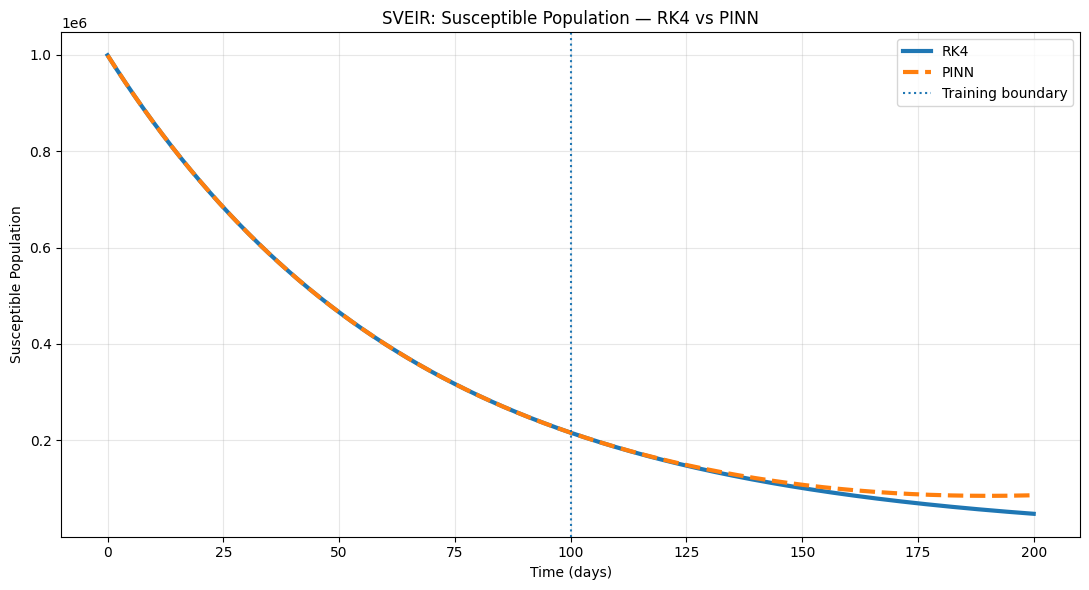

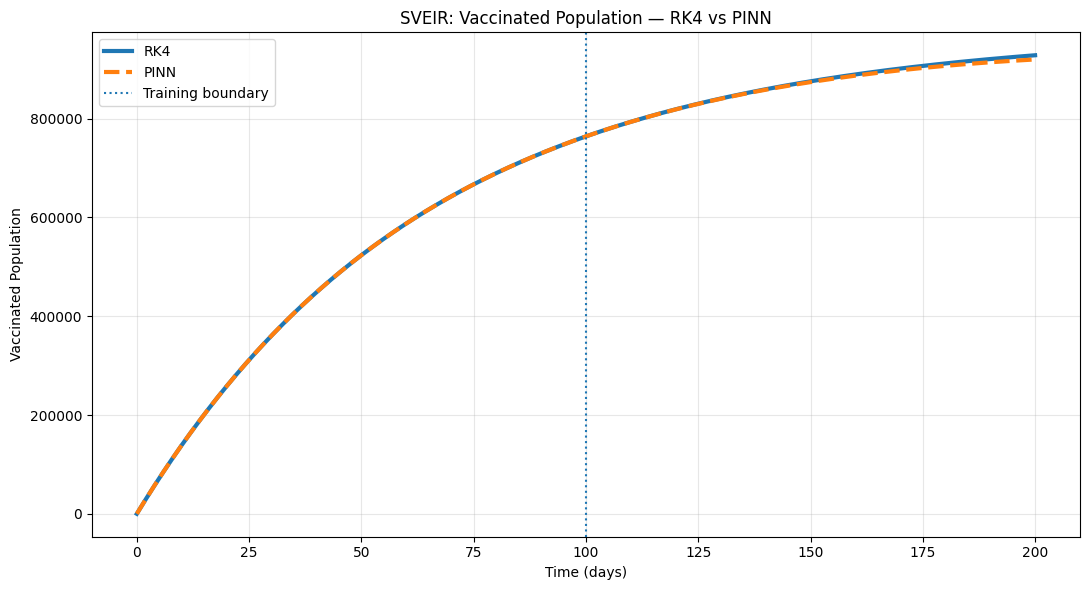

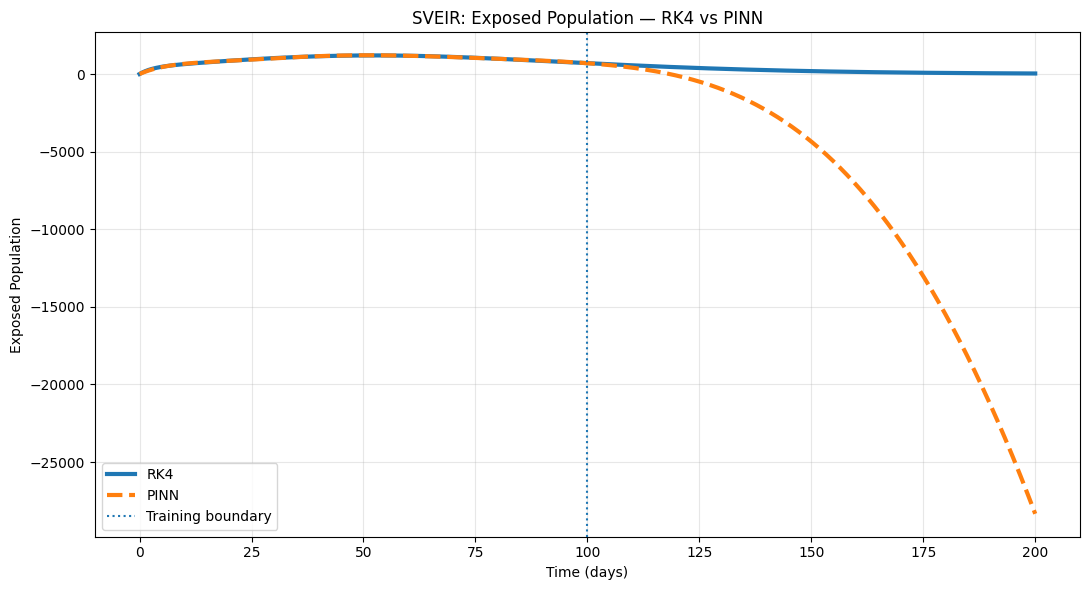

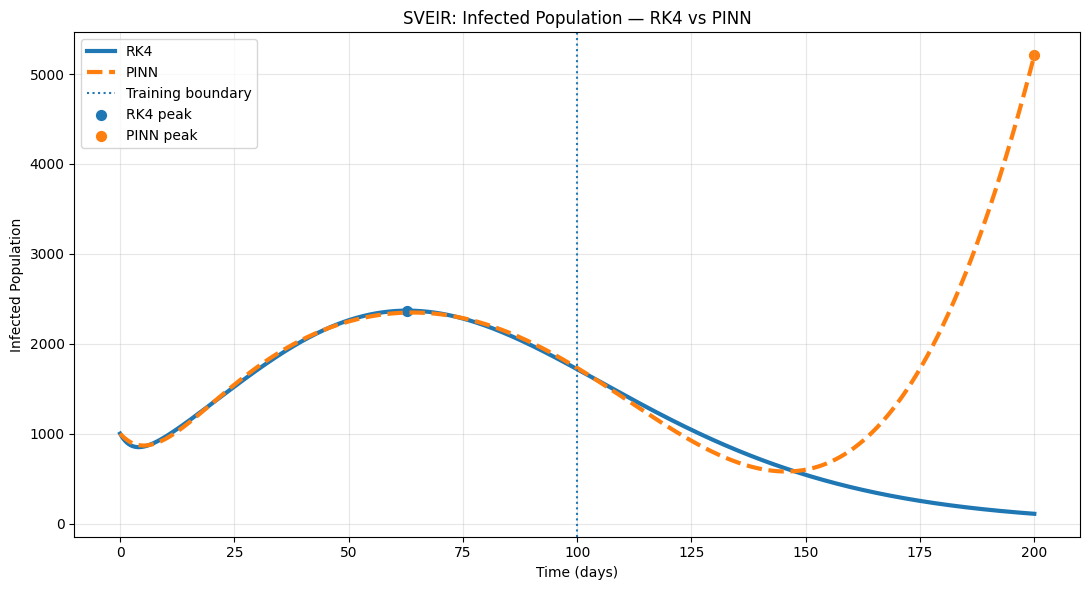

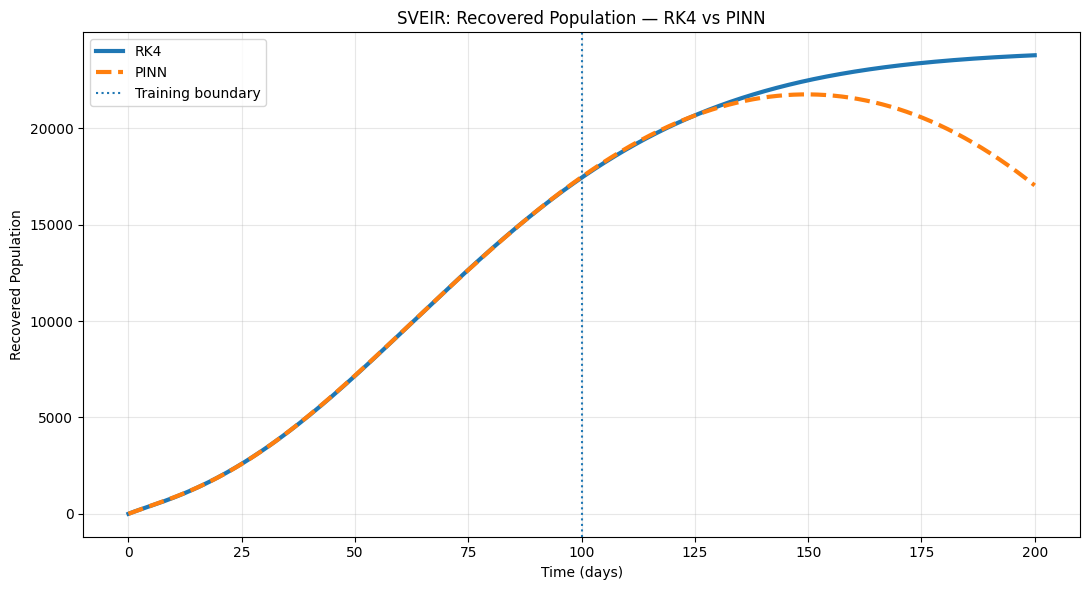

In [40]:
# =============================================================================
# PLOT — S COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    S_rk4,
    label="RK4",
    linewidth=3
)

plt.plot(
    t_eval,
    S_pinn,
    "--",
    label="PINN",
    linewidth=3
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Susceptible Population"
)

plt.title(
    "SVEIR: Susceptible Population — RK4 vs PINN"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_S.png",
    dpi=300
)

plt.show()


# =============================================================================
# PLOT — V COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    V_rk4,
    label="RK4",
    linewidth=3
)

plt.plot(
    t_eval,
    V_pinn,
    "--",
    label="PINN",
    linewidth=3
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Vaccinated Population"
)

plt.title(
    "SVEIR: Vaccinated Population — RK4 vs PINN"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_V.png",
    dpi=300
)

plt.show()


# =============================================================================
# PLOT — E COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    E_rk4,
    label="RK4",
    linewidth=3
)

plt.plot(
    t_eval,
    E_pinn,
    "--",
    label="PINN",
    linewidth=3
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Exposed Population"
)

plt.title(
    "SVEIR: Exposed Population — RK4 vs PINN"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_E.png",
    dpi=300
)

plt.show()


# =============================================================================
# PLOT — I COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    I_rk4,
    label="RK4",
    linewidth=3
)

plt.plot(
    t_eval,
    I_pinn,
    "--",
    label="PINN",
    linewidth=3
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.scatter(
    rk4_peak_time,
    rk4_peak_I,
    s=50,
    label="RK4 peak"
)

plt.scatter(
    pinn_peak_time,
    pinn_peak_I,
    s=50,
    label="PINN peak"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Infected Population"
)

plt.title(
    "SVEIR: Infected Population — RK4 vs PINN"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_I.png",
    dpi=300
)

plt.show()


# =============================================================================
# PLOT — R COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    R_rk4,
    label="RK4",
    linewidth=3
)

plt.plot(
    t_eval,
    R_pinn,
    "--",
    label="PINN",
    linewidth=3
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Recovered Population"
)

plt.title(
    "SVEIR: Recovered Population — RK4 vs PINN"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_R.png",
    dpi=300
)

plt.show()

## All three compartments (S, V, E, I, R) in one figure

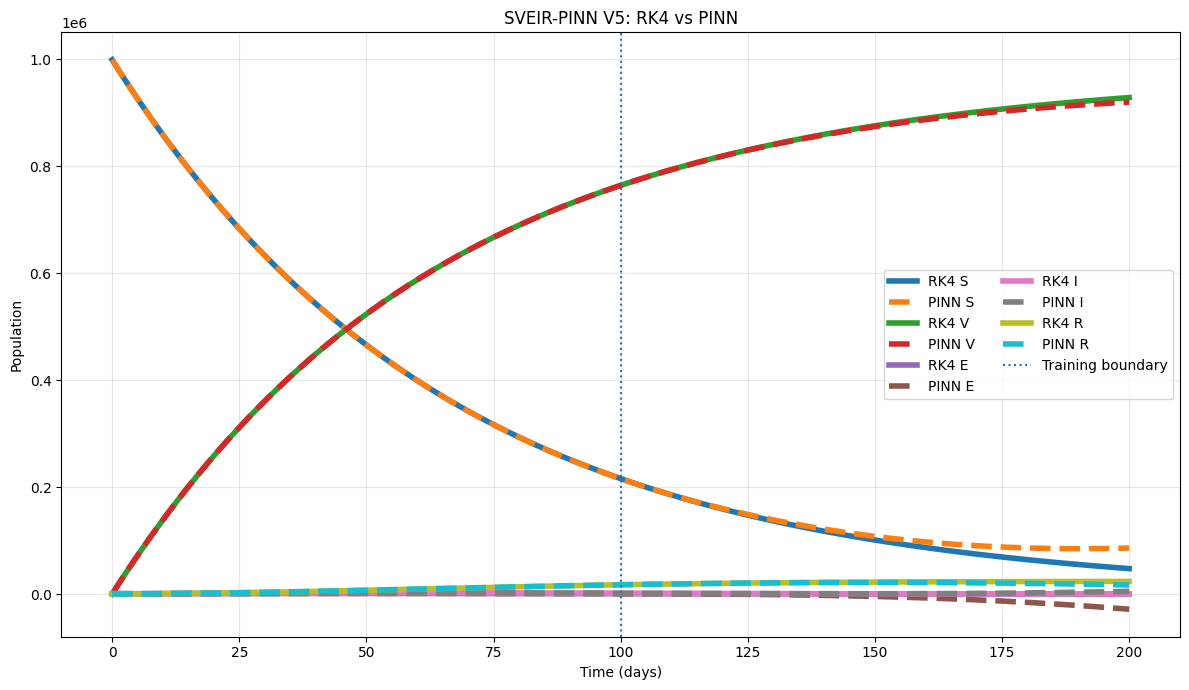

In [41]:
# =============================================================================
# ALL COMPARTMENTS
# =============================================================================

plt.figure(
    figsize=(12, 7)
)

# --- S Compartment ---
plt.plot(
    t_eval,
    S_rk4,
    label="RK4 S",
    linewidth=4
)
plt.plot(
    t_eval,
    S_pinn,
    "--",
    label="PINN S",
    linewidth=4
)

# --- V Compartment ---
plt.plot(
    t_eval,
    V_rk4,
    label="RK4 V",
    linewidth=4
)
plt.plot(
    t_eval,
    V_pinn,
    "--",
    label="PINN V",
    linewidth=4
)

# --- E Compartment ---
plt.plot(
    t_eval,
    E_rk4,
    label="RK4 E",
    linewidth=4
)
plt.plot(
    t_eval,
    E_pinn,
    "--",
    label="PINN E",
    linewidth=4
)

# --- I Compartment ---
plt.plot(
    t_eval,
    I_rk4,
    label="RK4 I",
    linewidth=4
)
plt.plot(
    t_eval,
    I_pinn,
    "--",
    label="PINN I",
    linewidth=4
)

# --- R Compartment ---
plt.plot(
    t_eval,
    R_rk4,
    label="RK4 R",
    linewidth=4
)
plt.plot(
    t_eval,
    R_pinn,
    "--",
    label="PINN R",
    linewidth=4
)

# --- Bounds & Layout ---
plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Population"
)

plt.title(
    "SVEIR-PINN V5: RK4 vs PINN"
)

plt.legend(
    ncol=2
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_v5_all_compartments.png",
    dpi=300
)

plt.show()

# INFECTED PEAK ZOOM

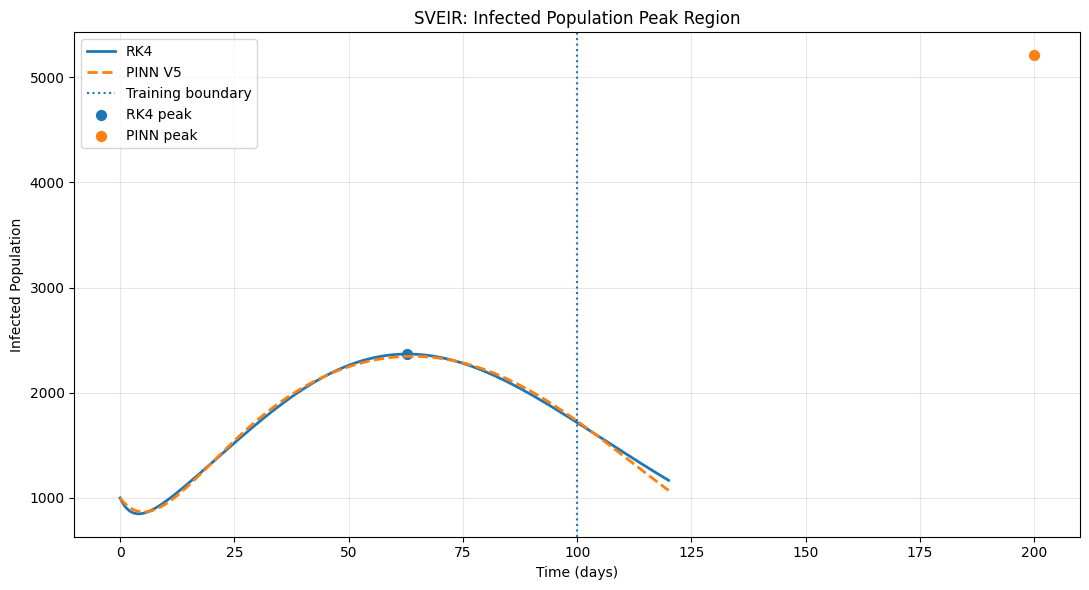

In [42]:
# =============================================================================
# INFECTED PEAK ZOOM
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

zoom_mask = (
    t_eval <= 120
)

plt.plot(
    t_eval[zoom_mask],
    I_rk4[zoom_mask],
    label="RK4",
    linewidth=2
)

plt.plot(
    t_eval[zoom_mask],
    I_pinn[zoom_mask],
    "--",
    label="PINN V5",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.scatter(
    rk4_peak_time,
    rk4_peak_I,
    s=50,
    label="RK4 peak"
)

plt.scatter(
    pinn_peak_time,
    pinn_peak_I,
    s=50,
    label="PINN peak"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Infected Population"
)

plt.title(
    "SVEIR: Infected Population Peak Region"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_v5_infected_zoom.png",
    dpi=300
)

plt.show()

# ABSOLUTE ERROR

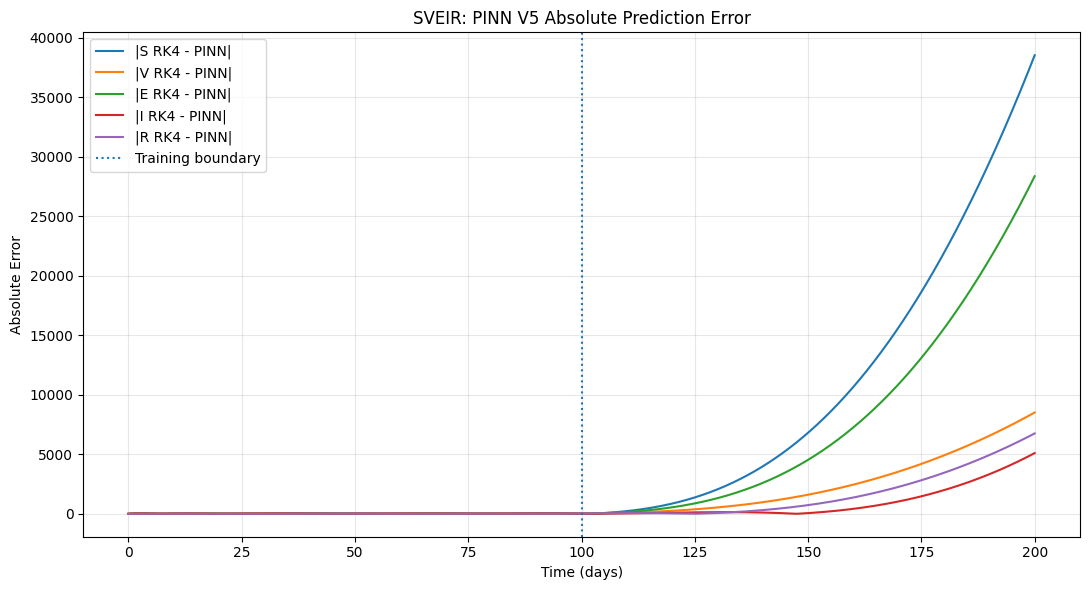

In [43]:
# =============================================================================
# ABSOLUTE ERROR
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    np.abs(
        S_rk4 - S_pinn
    ),
    label="|S RK4 - PINN|"
)

plt.plot(
    t_eval,
    np.abs(
        V_rk4 - V_pinn
    ),
    label="|V RK4 - PINN|"
)

plt.plot(
    t_eval,
    np.abs(
        E_rk4 - E_pinn
    ),
    label="|E RK4 - PINN|"
)

plt.plot(
    t_eval,
    np.abs(
        I_rk4 - I_pinn
    ),
    label="|I RK4 - PINN|"
)

plt.plot(
    t_eval,
    np.abs(
        R_rk4 - R_pinn
    ),
    label="|R RK4 - PINN|"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Absolute Error"
)

plt.title(
    "SVEIR: PINN V5 Absolute Prediction Error"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_v5_absolute_errors.png",
    dpi=300
)

plt.show()

# CONSERVATION ERROR

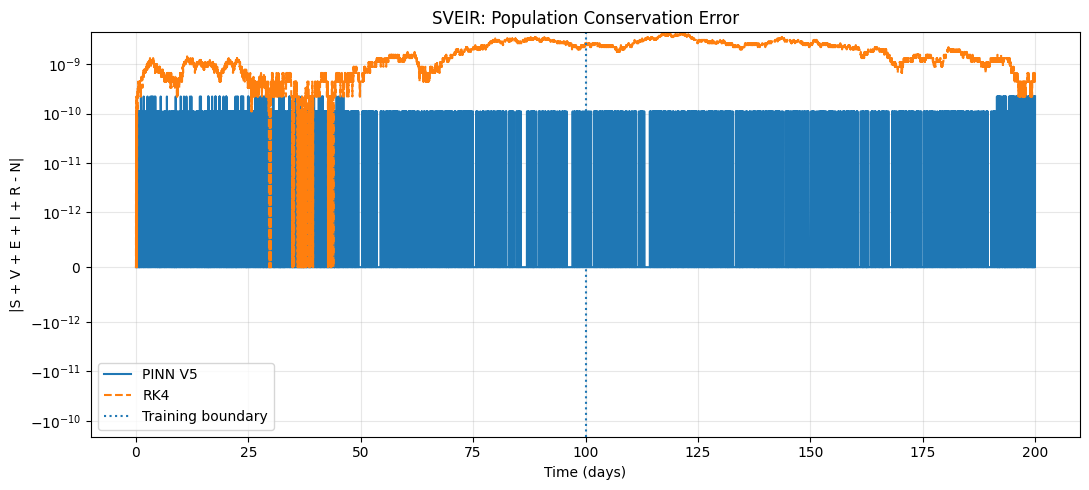

In [44]:
# =============================================================================
# CONSERVATION ERROR
# =============================================================================

plt.figure(
    figsize=(11, 5)
)

plt.plot(
    t_eval,
    pinn_conservation_error,
    label="PINN V5"
)

plt.plot(
    t_eval,
    rk4_conservation_error,
    "--",
    label="RK4"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "|S + V + E + I + R - N|"
)

plt.title(
    "SVEIR: Population Conservation Error"
)

plt.yscale(
    "symlog",
    linthresh=1e-12
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_v5_conservation.png",
    dpi=300
)

plt.show()

# ADAM LOSS

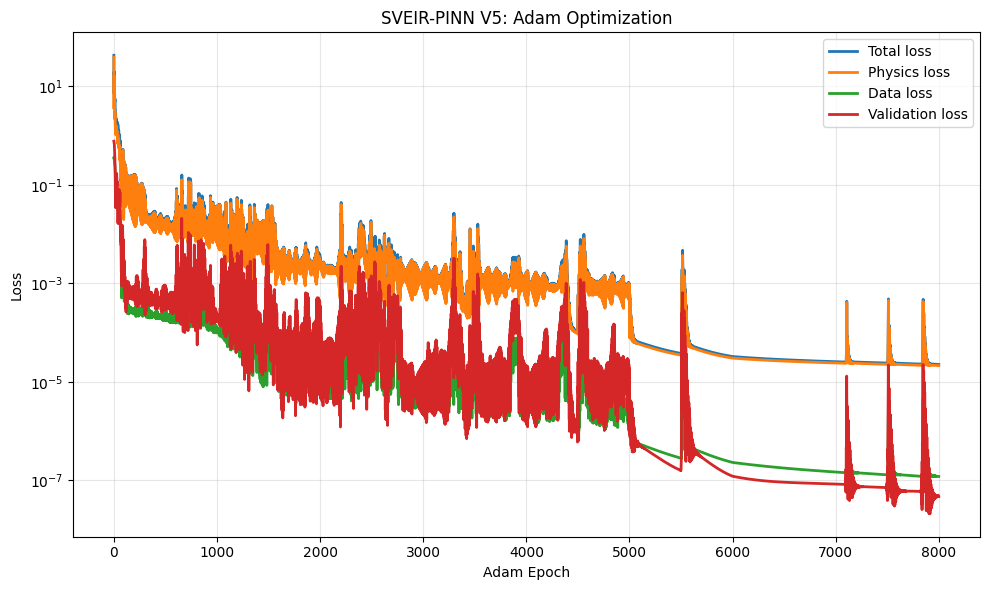

In [45]:
# =============================================================================
# ADAM LOSS
# =============================================================================

plt.figure(
    figsize=(10, 6)
)

plt.semilogy(
    loss_history,
    label="Total loss",
    linewidth=2
)

plt.semilogy(
    physics_history,
    label="Physics loss",
    linewidth=2
)

plt.semilogy(
    data_history,
    label="Data loss",
    linewidth=2
)

plt.semilogy(
    val_history,
    label="Validation loss",
    linewidth=2
)

plt.xlabel(
    "Adam Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "SVEIR-PINN V5: Adam Optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_v5_adam_loss.png",
    dpi=300
)

plt.show()

## L-BFGS LOSS

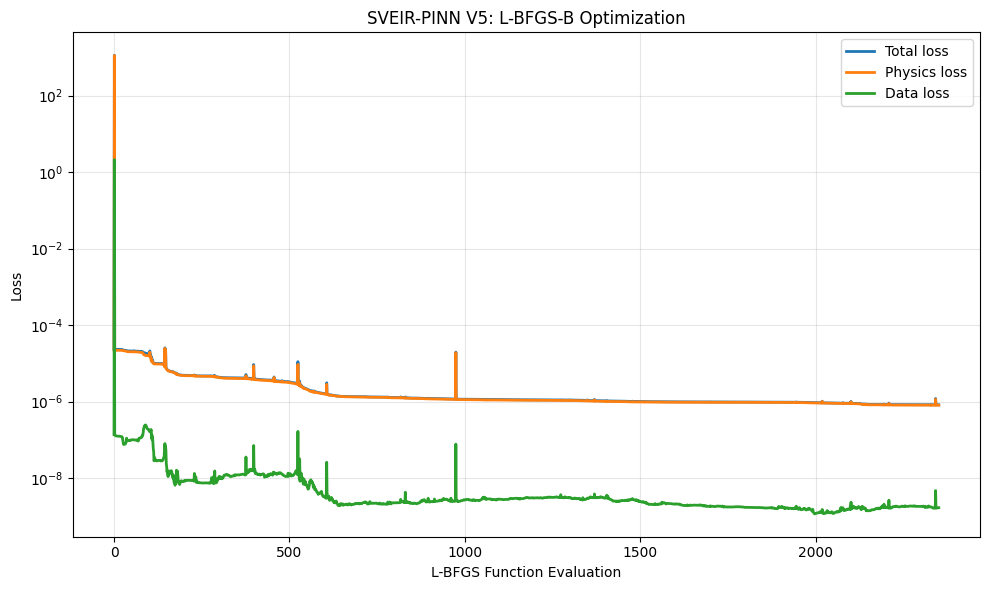

In [46]:
# =============================================================================
# L-BFGS LOSS
# =============================================================================

if len(lbfgs_loss_history) > 0:

    plt.figure(
        figsize=(10, 6)
    )

    plt.semilogy(
        lbfgs_loss_history,
        label="Total loss",
        linewidth=2
    )

    plt.semilogy(
        lbfgs_physics_history,
        label="Physics loss",
        linewidth=2
    )

    plt.semilogy(
        lbfgs_data_history,
        label="Data loss",
        linewidth=2
    )

    plt.xlabel(
        "L-BFGS Function Evaluation"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        "SVEIR-PINN V5: L-BFGS-B Optimization"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        "sveir_pinn_v5_lbfgs_loss.png",
        dpi=300
    )

    plt.show()

## PHYSICS RESIDUAL PLOT

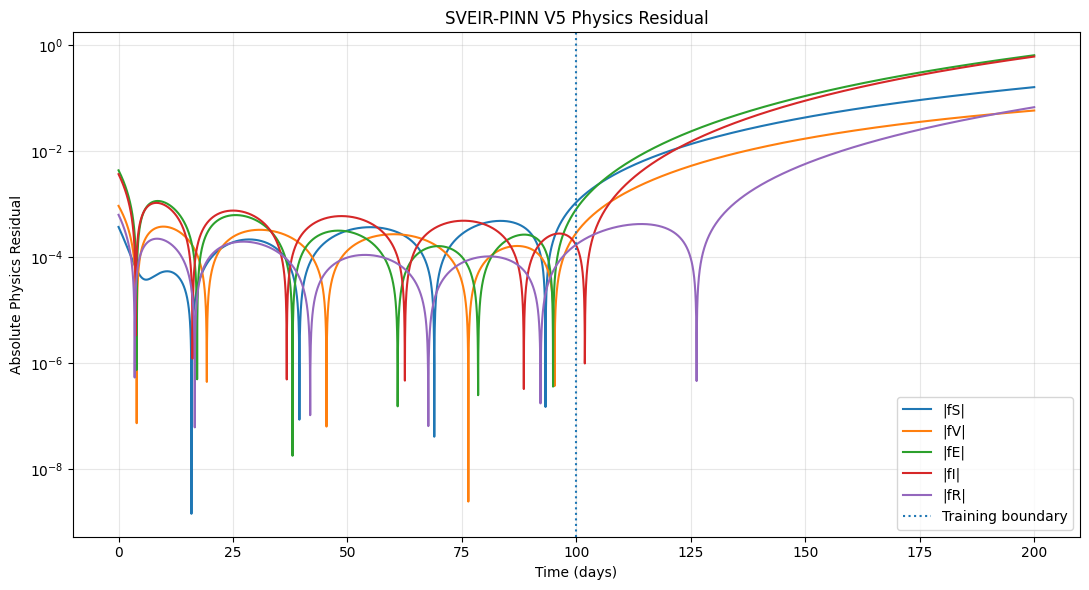

In [47]:
# =============================================================================
# PHYSICS RESIDUAL PLOT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

# --- S Residual ---
plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_s_train_np,
            f_s_extra_np
        ])
    ) + 1e-30,
    label="|fS|"
)

# --- V Residual ---
plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_v_train_np,
            f_v_extra_np
        ])
    ) + 1e-30,
    label="|fV|"
)

# --- E Residual ---
plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_e_train_np,
            f_e_extra_np
        ])
    ) + 1e-30,
    label="|fE|"
)

# --- I Residual ---
plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_i_train_np,
            f_i_extra_np
        ])
    ) + 1e-30,
    label="|fI|"
)

# --- R Residual ---
plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_r_train_np,
            f_r_extra_np
        ])
    ) + 1e-30,
    label="|fR|"
)

# --- Bounds & Layout ---
plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Absolute Physics Residual"
)

plt.title(
    "SVEIR-PINN V5 Physics Residual"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sveir_pinn_v5_physics_residual.png",
    dpi=300
)

plt.show()

## FINAL SUMMARY

In [48]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

print()
print()
print("=" * 90)
print("FINAL SVEIR-PINN SUMMARY")
print("=" * 90)

print()
print("MODEL")
print("-" * 90)

print(
    "Architecture: "
    "5 hidden layers × 64 neurons, tanh"
)

print(
    "Outputs: "
    "4 neural outputs + analytical R"
)

print(
    "Precision: float64"
)

print()
print("PARAMETERS")
print("-" * 90)

print(
    f"Beta  = {BETA:.8f}"
)


print(
    f"Sigma = {SIGMA:.8f}"
)

print(
    f"Gamma = {GAMMA:.8f}"
)

# Example SVEIR R0 formula assuming negligible natural mortality (mu = 0)
# Update this expression if your specific SVEIR formulation uses explicit vaccine efficacy or vital dynamics
print(
    f"R0    = {BETA / GAMMA:.8f}"
)

print()
print("OPTIMIZATION")
print("-" * 90)

print(
    f"Adam epochs        = {ADAM_EPOCHS}"
)

print(
    f"Adam final physics = "
    f"{final_physics_loss.numpy():.12e}"
)

print(
    f"Adam/L-BFGS data loss = "
    f"{final_train_data_loss.numpy():.12e}"
)

print(
    f"Validation loss    = "
    f"{final_validation_loss.numpy():.12e}"
)

print(
    f"L-BFGS success     = "
    f"{result.success}"
)

print(
    f"Total Adam time    = "
    f"{adam_time:.3f} sec"
)

print(
    f"Total L-BFGS time  = "
    f"{lbfgs_time:.3f} sec"
)

print()
print("PEAK INFECTION")
print("-" * 90)

print(
    f"RK4  = "
    f"{rk4_peak_I:,.4f} "
    f"at {rk4_peak_time:.4f} days"
)

print(
    f"PINN = "
    f"{pinn_peak_I:,.4f} "
    f"at {pinn_peak_time:.4f} days"
)

print(
    f"Peak value error = "
    f"{peak_value_error:.8f}%"
)

print(
    f"Peak timing error = "
    f"{peak_time_error:.8f} days"
)

print()
print("PHYSICS")
print("-" * 90)

print(
    f"0-100 residual RMSE = "
    f"{train_physics_rmse:.12e}"
)

print(
    f"100-200 residual RMSE = "
    f"{extra_physics_rmse:.12e}"
)

print()
print("CONSERVATION")
print("-" * 90)

print(
    f"Maximum PINN conservation error = "
    f"{np.max(pinn_conservation_error):.12e}"
)

print()
print("FILES SAVED")
print("-" * 90)

files_to_save = [
    "sveir_pinn_results.csv",
    "sveir_pinn_metrics.csv",
    "sveir_pinn_training_history.csv",
    "sveir_pinn_lbfgs_history.csv",
    "sveir_pinn.weights.h5",
    "sveir_pinn_S.png",
    "sveir_pinn_V.png",
    "sveir_pinn_E.png",
    "sveir_pinn_I.png",
    "sveir_pinn_R.png",
    "sveir_pinn_all_compartments.png",
    "sveir_pinn_infected_zoom.png",
    "sveir_pinn_absolute_errors.png",
    "sveir_pinn_conservation.png",
    "sveir_pinn_adam_loss.png",
    "sveir_pinn_lbfgs_loss.png",
    "sveir_pinn_physics_residual.png"
]

for filename in files_to_save:
    print(filename)

print()
print("=" * 90)
print("SVEIR-PINN V5 COMPLETE")
print("=" * 90)



FINAL SVEIR-PINN SUMMARY

MODEL
------------------------------------------------------------------------------------------
Architecture: 5 hidden layers × 64 neurons, tanh
Outputs: 4 neural outputs + analytical R
Precision: float64

PARAMETERS
------------------------------------------------------------------------------------------
Beta  = 0.17150948
Sigma = 0.19230769
Gamma = 0.09425424
R0    = 1.81964737

OPTIMIZATION
------------------------------------------------------------------------------------------
Adam epochs        = 8000
Adam final physics = 8.056188282806e-07
Adam/L-BFGS data loss = 1.678257738847e-09
Validation loss    = 2.648207676150e-09
L-BFGS success     = False
Total Adam time    = 597.164 sec
Total L-BFGS time  = 77.831 sec

PEAK INFECTION
------------------------------------------------------------------------------------------
RK4  = 2,368.2326 at 62.8400 days
PINN = 5,209.0009 at 200.0000 days
Peak value error = 119.95308955%
Peak timing error = 137.16000000